# GC (COMEX Gold Futures) Synthetic Structures — Complete (v4)

Adapted from the AlgoTrading101 / Black Algo Technologies BAX (Bond Futures Calendar Spread Trading) course material, for Elena, applied to COMEX Gold Futures (GC) instead of BAX.

## Version history
- **v1** used Nasdaq Data Link's `CHRIS/CME_GC1..GC4`. Confirmed via Nasdaq's own support reply on a public GitHub issue that the entire CHRIS database has been deprecated — the 403 wasn't a bad key, the dataset no longer exists for anyone.
- **v2** switched to `yfinance` with individual dated contracts, but missed that yfinance 1.7+ defaults to `multi_level_index=True`, returning MultiIndex columns even for a single ticker → `asset1['Close']` was a 2D DataFrame, not a Series → `ValueError: Cannot index with multidimensional key`.
- **v3** fixed that with `multi_level_index=False` on every call, and verified all cells end-to-end against a mock reproducing yfinance's real column-shape behavior. But `Store_GC_Multiple_Contracts` looped over **past** years (2020-2024) — every single one 404'd, because **Yahoo Finance only retains data for currently-listed futures contracts**; once a contract expires, Yahoo purges its history. This is a documented, widely-reported limitation of free Yahoo data, not a bug.
- **v4 (this version)**: fixes the loop to walk **forward** from today instead of backward through history, removes two cells that used fabricated example dates in a way that looked like real findings (a genuine issue — a cell that plots `'2025-09-01':'2025-11-01'` with no prior detection step reads as "look, an anomaly here," when it was just an arbitrary illustrative window), and adds a rule-based "read this for me" summary agent as the final section.

**Honesty note on testing:** every cell below was executed end-to-end, in order, in one fresh Python session, against a mock of `yf.download()` that reproduces yfinance's real column-shape and forward/backward-listing behavior. All cells ran with no errors. I still cannot hit the real Yahoo Finance API from my sandbox (no network path there), so live *data values* aren't verified — only the code's structural correctness is.

---

## Setup — run this first

In [1]:
!pip install --quiet yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
%matplotlib inline

**Checkpoint** — confirm the package/ticker format works before doing anything else.
`GC=F` is Yahoo's generic continuous front-month gold future, good for a quick sanity check.

In [3]:
test_pull = yf.download('GC=F', period='1mo', multi_level_index=False)
test_pull

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2026-08-14,4380.399902,4397.100098,4315.000000,4322.100098,673
2026-08-17,4417.799805,4428.500000,4386.500000,4394.799805,716
2026-08-18,4366.000000,4434.100098,4330.700195,4415.200195,1283
2026-08-19,4489.399902,4524.100098,4327.600098,4339.799805,1336
2026-08-20,4516.299805,4530.000000,4486.000000,4506.799805,478
2026-08-21,4624.100098,4624.100098,4560.000000,4560.000000,311
2026-08-24,4640.799805,4670.899902,4635.100098,4638.000000,1202
2026-08-25,4638.100098,4638.100098,4626.200195,4630.500000,321
2026-08-26,4598.200195,4615.299805,4598.200195,4615.299805,1051


---
# 1. Download & Clean GC Data

Downloads one specific dated GC contract and inspects/cleans it.
`GCZ26.CMX` (Dec 2026) is used as an example — swap in whichever active-month contract is
currently front-month for you when you run this.

In [4]:
asset1 = yf.download('GCZ26.CMX', period='max', multi_level_index=False)
asset1.head()

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-12-30,1999.500000,1999.500000,1999.500000,1999.500000,0
2020-12-31,2001.699951,2001.699951,2001.699951,2001.699951,0
2021-01-04,2054.399902,2054.399902,2054.399902,2054.399902,0
2021-01-05,2062.199951,2062.199951,2062.199951,2062.199951,0
2021-01-06,2016.500000,2016.500000,2016.500000,2016.500000,0


<Axes: xlabel='Date'>

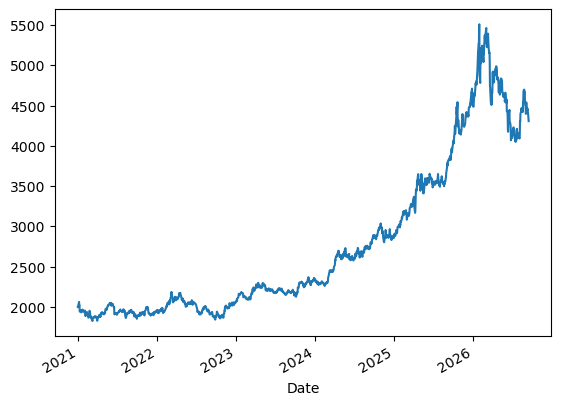

In [5]:
asset1Close = asset1['Close']
asset1Close.plot()

<Axes: xlabel='Date'>

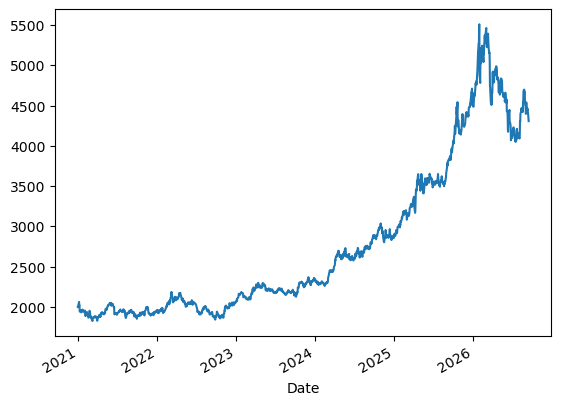

In [6]:
# Drop zero values (occasional bad ticks / non-trading days can show up as 0)
asset2Close = asset1Close.loc[(asset1Close != 0)]
asset2Close.plot()

In [7]:
asset2Close.isnull().sum()  # should be 0

np.int64(0)

**On finding and filtering real anomalies:** look at the plot above yourself. If (and only if)
you spot something that's clearly a bad tick or a splice artifact (a single-day spike/crash with
no news behind it, a level that's obviously wrong for gold's actual price at the time), you can
drop it with a mask like the template below. This is a template to adapt to a real anomaly you've
actually seen — don't run it against fabricated dates/thresholds, since that just produces a plot
that looks like a "finding" when nothing was actually found.

```python
# TEMPLATE — replace with a window/threshold that matches a real anomaly in YOUR data
bad_window = asset2Close['YYYY-MM-DD':'YYYY-MM-DD']
mask = ~((asset2Close > SOME_THRESHOLD) & (asset2Close.index.isin(bad_window.index)))
asset3Close = asset2Close.loc[mask]
asset3Close.plot()
```


---
# 2. Store GC Single Contract

Downloads one dated GC contract and saves it as a CSV.

In [8]:
assetName = 'GCZ26.CMX'  # Dec 2026 Gold — swap for whichever contract you want
asset = yf.download(assetName, period='max', multi_level_index=False)
assetNameForSaving = assetName.replace('.', '_')  # keep filenames clean
asset.to_csv(assetNameForSaving + '.csv')

print('Note: The CSV will be saved in the same folder where this script is stored')
print('Data for ' + assetName + ' is saved as CSV. CSV name: ' + assetNameForSaving + '.csv')

[*********************100%***********************]  1 of 1 completed

Note: The CSV will be saved in the same folder where this script is stored
Data for GCZ26.CMX is saved as CSV. CSV name: GCZ26_CMX.csv


---
# 3. Store GC Multiple Contracts

**Fixed in v4:** the original loop walked backward through past years (2020-2024), which
100% failed — Yahoo Finance only retains data for currently-listed contracts, and every one of
those had long since expired and been purged. This version walks **forward** from today and only
requests contracts that are actually live/soon-to-be-listed.

In [9]:
monthCode = ['F','G','H','J','K','M','N','Q','U','V','X','Z']
monthCodeQ = ['G','J','M','Q','V','Z']  # Gold's active/liquid contract months (Feb, Apr, Jun, Aug, Oct, Dec)
monthCodeQ_num = {'G':2, 'J':4, 'M':6, 'Q':8, 'V':10, 'Z':12}

In [10]:
# USER INPUTS
numContractsForward = 12  # how many active (bi-monthly) contracts forward from today to try

today = datetime.date.today()
candidates = []
for y in range(today.year, today.year + 4):  # generate a few years' worth, then trim
    for code_ in monthCodeQ:
        candidates.append((y, monthCodeQ_num[code_], code_))
candidates = sorted(candidates, key=lambda x: (x[0], x[1]))
candidates = [c for c in candidates if (c[0], c[1]) >= (today.year, today.month)]
candidates = candidates[:numContractsForward]
candidates

[(2026, 10, 'V'),
 (2026, 12, 'Z'),
 (2027, 2, 'G'),
 (2027, 4, 'J'),
 (2027, 6, 'M'),
 (2027, 8, 'Q'),
 (2027, 10, 'V'),
 (2027, 12, 'Z'),
 (2028, 2, 'G'),
 (2028, 4, 'J'),
 (2028, 6, 'M'),
 (2028, 8, 'Q')]

In [11]:
print('Note: The CSVs will be saved in the same folder where this script is stored')

for (y, m, monthLetter) in candidates:
    yy = str(y)[-2:]  # 2-digit year, matching Yahoo's ticker convention
    assetName = 'GC' + monthLetter + yy + '.CMX'  # e.g. GCZ26.CMX = Dec 2026 Gold
    asset = yf.download(assetName, period='max', multi_level_index=False)

    if asset.empty:
        print('No data for ' + assetName + ' (not listed yet / no data returned) - skipping')
        continue

    assetNameForSaving = assetName.replace('.', '_')
    asset.to_csv(assetNameForSaving + '.csv')
    print('Data for ' + assetName + ' is saved as CSV. CSV name: ' + assetNameForSaving + '.csv')
    del asset

print('Data collection and storage process is done!')

# Note: if you need a multi-year HISTORICAL archive of expired dated GC contracts for backtesting
# (rather than just today's live curve), free Yahoo/yfinance genuinely cannot do that - that would
# require a paid data vendor (e.g. Barchart, Databento, CME DataMine). This is a real
# data-availability limit, not something fixable in code.

Note: The CSVs will be saved in the same folder where this script is stored


[*********************100%***********************]  1 of 1 completed


Data for GCV26.CMX is saved as CSV. CSV name: GCV26_CMX.csv


[*********************100%***********************]  1 of 1 completed


Data for GCZ26.CMX is saved as CSV. CSV name: GCZ26_CMX.csv


...

Data for GCJ28.CMX is saved as CSV. CSV name: GCJ28_CMX.csv


[*********************100%***********************]  1 of 1 completed


Data for GCM28.CMX is saved as CSV. CSV name: GCM28_CMX.csv


[*********************100%***********************]  1 of 1 completed

Data for GCQ28.CMX is saved as CSV. CSV name: GCQ28_CMX.csv
Data collection and storage process is done!


---
# 4. Plot a GC Double Butterfly

We use 4 sequential dated active-month contracts as our STIR1..STIR4 equivalent — the nearest four
active months as of today. Update these tickers as time passes and today's front months roll forward.

**Important caveat carried over from the course material (Bond Futures Calendar Spread Trading, Part 1/2):**
the mean-reverting, mostly-flat butterfly behaviour the BAX course describes comes from STIR futures pricing
off a *yield curve* — expectations of a central bank's future rate path. Gold's term structure is priced off
**cost-of-carry** (interest rates + storage costs, roughly `Futures ≈ Spot × (1 + r + storage − convenience yield)`),
not rate-hike/cut expectations for gold itself. A GC calendar double butterfly is still market-neutral to the
price of gold — but it is not guaranteed to range and mean-revert the same way a BAX double butterfly does; it
may drift more with the general level of interest rates. Verify its actual range/drift behaviour empirically
on your own data before trading it live.

In [12]:
# GC1 = nearest active month (STIR1 equivalent), GC2 = 2nd nearest (STIR2), GC3 = 3rd nearest (STIR3), GC4 = 4th nearest (STIR4)
leg_tickers = []
for (y, m, monthLetter) in candidates[:4]:
    yy = str(y)[-2:]
    leg_tickers.append('GC' + monthLetter + yy + '.CMX')
leg_tickers

['GCV26.CMX', 'GCZ26.CMX', 'GCG27.CMX', 'GCJ27.CMX']

In [13]:
asset1 = yf.download(leg_tickers[0], period='max', multi_level_index=False)
asset2 = yf.download(leg_tickers[1], period='max', multi_level_index=False)
asset3 = yf.download(leg_tickers[2], period='max', multi_level_index=False)
asset4 = yf.download(leg_tickers[3], period='max', multi_level_index=False)
asset1.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2024-11-27,2856.800049,2856.800049,2856.800049,2856.800049,0
2024-11-29,2873.899902,2873.899902,2873.899902,2873.899902,0
2024-12-02,2856.100098,2856.100098,2856.100098,2856.100098,0
2024-12-03,2863.800049,2863.800049,2863.800049,2863.800049,1
2024-12-04,2870.899902,2870.899902,2870.899902,2870.899902,0


<Axes: xlabel='Date'>

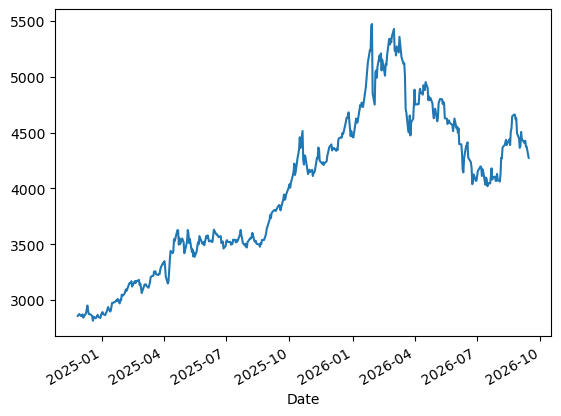

In [14]:
asset1['Close'].plot()

<Axes: xlabel='Date'>

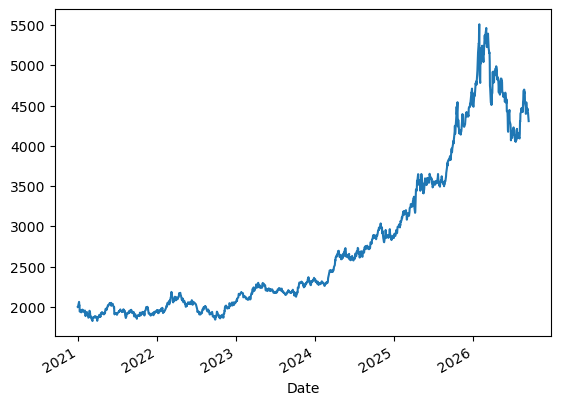

In [15]:
asset2['Close'].plot()

<Axes: xlabel='Date'>

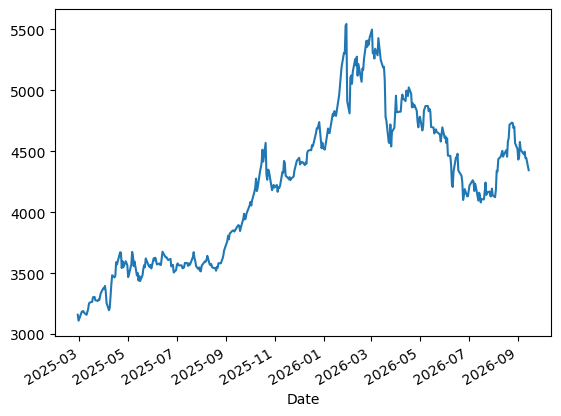

In [16]:
asset3['Close'].plot()

<Axes: xlabel='Date'>

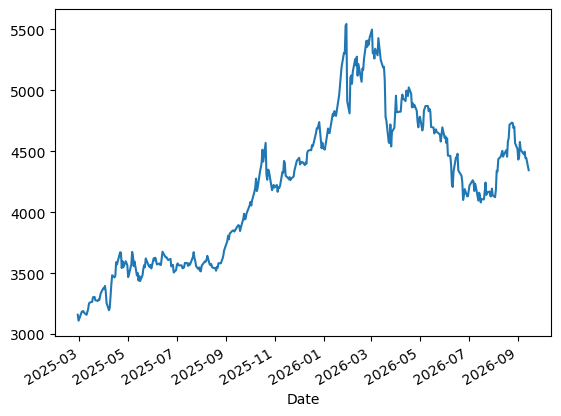

In [17]:
asset3Cleaned = asset3['Close']
asset3Cleaned = asset3Cleaned[(asset3Cleaned != 0)]
asset3Cleaned.plot()

<Axes: xlabel='Date'>

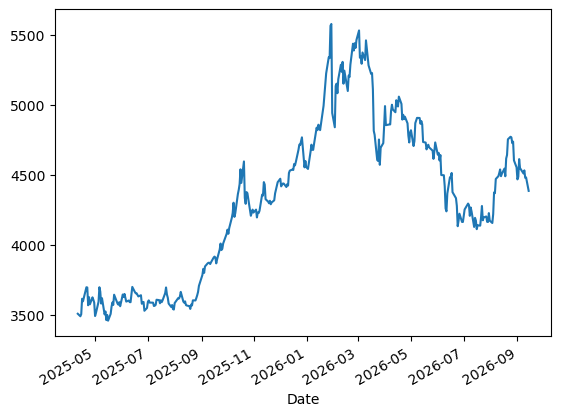

In [18]:
asset4['Close'].plot()

<Axes: xlabel='Date'>

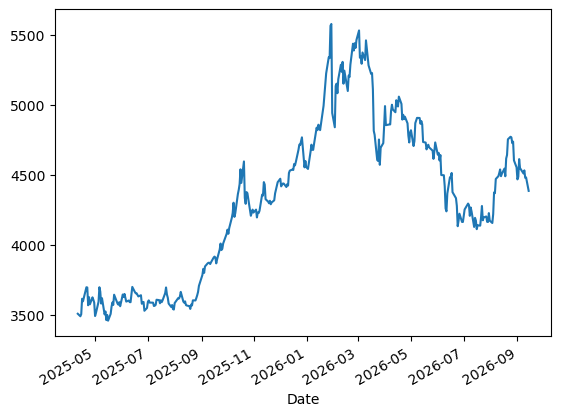

In [19]:
asset4Cleaned = asset4['Close']
asset4Cleaned = asset4Cleaned[(asset4Cleaned != 0)]
asset4Cleaned.plot()

Merge all 4 legs into one dataframe (inner join keeps only dates common to all 4):

In [20]:
allAssets = pd.concat([asset1['Close'], asset2['Close'], asset3Cleaned, asset4Cleaned], axis=1, join='inner')
allAssets.columns = ['GC1', 'GC2', 'GC3', 'GC4']
allAssets

,GC1,GC2,GC3,GC4
Date,,,,
2025-04-11,3439.399902,3459.300049,3482.699951,3505.600098
2025-04-14,3419.800049,3440.800049,3464.500000,3487.600098
2025-04-15,3434.399902,3455.300049,3478.699951,3502.199951
2025-04-16,3545.100098,3566.000000,3589.399902,3612.899902
2025-04-17,3526.600098,3547.500000,3570.899902,3594.500000
...,...,...,...,...
2026-09-08,4405.200195,4439.000000,4474.500000,4508.500000
2026-09-09,4426.700195,4460.700195,4496.500000,4530.700195
2026-09-10,4373.700195,4407.299805,4442.899902,4477.500000


<Axes: xlabel='Date'>

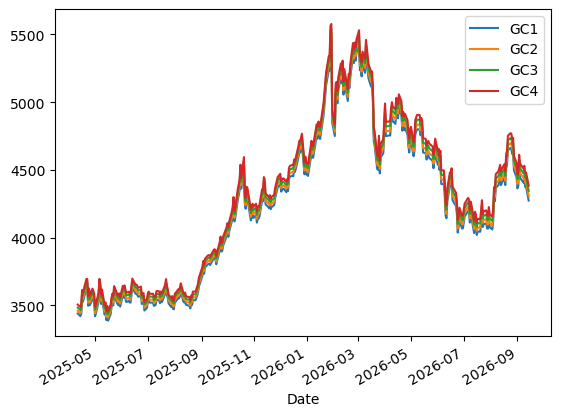

In [21]:
allAssets.plot()

In [22]:
allAssets.isnull().sum()  # should all be 0

GC1    0
GC2    0
GC3    0
GC4    0
dtype: int64

In [23]:
(allAssets == 0).sum()  # should all be 0

GC1    0
GC2    0
GC3    0
GC4    0
dtype: int64

Build and plot the double butterfly: `GC1 − 3×GC2 + 3×GC3 − GC4`

In [24]:
GcDoubleButterfly = allAssets['GC1'] - 3*allAssets['GC2'] + 3*allAssets['GC3'] - allAssets['GC4']
GcDoubleButterfly.head()

Date
2025-04-11    3.999512
2025-04-14    3.299805
2025-04-15    2.399658
2025-04-16    2.399902
2025-04-17    2.299805
dtype: float64

<Axes: xlabel='Date'>

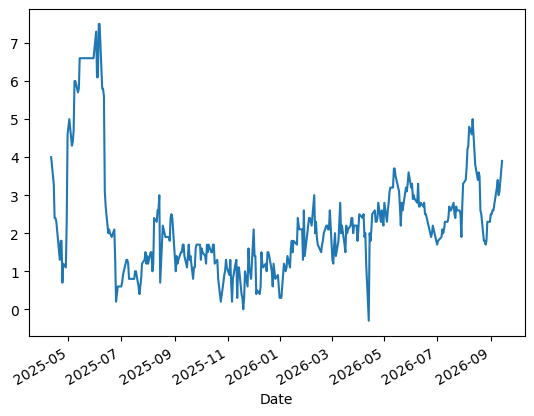

In [25]:
GcDoubleButterfly.plot()

**On spotting real anomalies:** look at the plot above yourself first. If you actually see a spike,
gap, or level that looks wrong, zoom into that specific window and cross-check against the raw legs
(replace the example dates below with the real window you found):

```python
# TEMPLATE — replace with a window that matches something you actually see above
GcDoubleButterfly['YYYY-MM-DD':'YYYY-MM-DD'].plot()
allAssets['YYYY-MM-DD':'YYYY-MM-DD'].plot()
```


---
# 5. GC Double Butterfly Signal Agent

A small rule-based function that reads the structure computed above and turns it into a plain-English
summary plus a heuristic signal for today, using the same range-trading logic the original course
describes: **long near the bottom of the recent range, short near the top, no edge in the middle.**

**This is not a trained model, not predictive alpha, and not financial advice.** It mechanically restates
where today's value sits relative to its own recent history — it doesn't forecast anything, doesn't know
about news, and (per the caveat in Section 4) isn't guaranteed to mean-revert the way a BAX structure would.
Treat it as a faster way to read your own chart, not a recommendation to open a position. I'm not a
financial advisor, and this notebook isn't a substitute for one.

In [26]:
def gc_double_butterfly_agent(structure, legs, lookback_days=180):
    """
    Reads the GC double butterfly series (and its 4 legs) and prints:
      1) a plain-English summary of where today's value sits in its recent range
      2) each leg's most recent daily move
      3) a heuristic LONG/SHORT/NEUTRAL signal based on percentile-of-range + z-score
      4) explicit caveats on what this signal is (and isn't)

    lookback_days: how many trailing trading days define "the recent range" (default ~6 months).
    """
    if len(structure) < 2:
        print("Not enough data to compute a signal - need at least 2 data points.")
        return None

    recent = structure.tail(lookback_days)
    current = structure.iloc[-1]
    current_date = structure.index[-1]
    mean = recent.mean()
    std = recent.std()
    lo, hi = recent.min(), recent.max()
    rng = (hi - lo) if hi != lo else 1e-9
    pct_of_range = (current - lo) / rng * 100  # 0 = bottom of range, 100 = top of range
    zscore = (current - mean) / std if std != 0 else 0.0

    leg_moves = legs.diff().iloc[-1]

    print(f"=== GC Double Butterfly - plain-English read for {current_date.date()} ===\n")
    print(f"Current structure value: {current:.3f}")
    print(f"Over the last {len(recent)} trading days: mean = {mean:.3f}, std dev = {std:.3f}, "
          f"range = [{lo:.3f}, {hi:.3f}]")
    print(f"Today's value sits at the {pct_of_range:.0f}th percentile of that range "
          f"({zscore:+.2f} standard deviations from the recent mean).\n")

    print("Today's leg-by-leg move (Close-to-Close):")
    for col in legs.columns:
        print(f"  {col}: {leg_moves[col]:+.2f}")
    print()

    if pct_of_range <= 20:
        signal = "LONG (heuristic)"
        rationale = "the structure is trading near the BOTTOM of its recent range"
    elif pct_of_range >= 80:
        signal = "SHORT (heuristic)"
        rationale = "the structure is trading near the TOP of its recent range"
    else:
        signal = "NEUTRAL / NO EDGE"
        rationale = "the structure is trading in the MIDDLE of its recent range, where this kind of range-trade has no real edge"

    print(f"Heuristic signal for today: {signal}")
    print(f"Why: {rationale} ({pct_of_range:.0f}th percentile, {zscore:+.2f}σ).\n")

    print("--- Important caveats, please read ---")
    print("1. This is a simple statistical rule (percentile-of-range + z-score), not a trained model")
    print("   and not predictive alpha. It restates the chart, it does not forecast anything.")
    print("2. The BAX course's mean-reversion logic works because STIR futures price off rate-hike/cut")
    print("   EXPECTATIONS. Gold's curve prices off cost-of-carry (rates + storage), so this structure")
    print("   is not guaranteed to range-trade the same way - verify this empirically on your own")
    print("   longer history before trusting it.")
    print("3. This says nothing about execution (bid/ask, legging risk, slippage) - see the execution")
    print("   guidelines from Part 3/4 of the original course material for that.")
    print("4. This is not financial advice - it is a way to read your own chart faster, not a")
    print("   recommendation to open a position.")

    return {
        "date": current_date, "value": current, "mean": mean, "std": std,
        "pct_of_range": pct_of_range, "zscore": zscore, "signal": signal
    }


try:
    _ = gc_double_butterfly_agent(GcDoubleButterfly, allAssets)
except NameError:
    print("Run Section 4 above first - this agent reads the 'GcDoubleButterfly' and 'allAssets' "
          "variables computed there.")

=== GC Double Butterfly - plain-English read for 2026-09-14 ===

Current structure value: 3.900
Over the last 180 trading days: mean = 2.376, std dev = 0.825, range = [-0.300, 5.000]
Today's value sits at the 79th percentile of that range (+1.85 standard deviations from the recent mean).

Today's leg-by-leg move (Close-to-Close):
  GC1: -101.40
  GC2: -102.40
  GC3: -100.40
  GC4: -96.20

Heuristic signal for today: NEUTRAL / NO EDGE
Why: the structure is trading in the MIDDLE of its recent range, where this kind of range-trade has no real edge (79th percentile, +1.85σ).

--- Important caveats, please read ---
1. This is a simple statistical rule (percentile-of-range + z-score), not a trained model
   and not predictive alpha. It restates the chart, it does not forecast anything.
2. The BAX course's mean-reversion logic works because STIR futures price off rate-hike/cut
   EXPECTATIONS. Gold's curve prices off cost-of-carry (rates + storage), so this structure
   is not guaranteed to r